In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, FuncFormatter
%matplotlib inline

In [2]:
time_packages = [
    "survivalgpu",
    "xgboost",
    "torchsurv"
]


In [3]:
packages_style = {
    "survivalgpu":         {"label": "ours",        "color": "#000000", "marker": "D", "ls": "--"},
    "xgboost":             {"label": "xgboost",         "color": "#8A8383", "marker": "o", "ls": "--"},
    "torchsurv":           {"label": "torchsurv", "color": "#00649E", "marker": "v", "ls": "-"},

}

In [6]:
data_path = Path("benchmark_results")
dataset_name = data_path / "2026_03_gpu_constant.csv"

dataset = pd.read_csv(dataset_name)
dataset

,experiment_name,package,n_patients,n_constant_covariates,n_time_dependent_covariates,device,computation_time
0,2026_03_gpu_constant,survivalgpu,500,1,0,cuda,0.960836
1,2026_03_gpu_constant,torchsurv,500,1,0,cuda,0.998935
2,2026_03_gpu_constant,xgboost,500,1,0,cuda,0.007265
3,2026_03_gpu_constant,survivalgpu,1000,1,0,cuda,0.339088
4,2026_03_gpu_constant,torchsurv,1000,1,0,cuda,1.500255
5,2026_03_gpu_constant,xgboost,1000,1,0,cuda,0.005316
6,2026_03_gpu_constant,survivalgpu,10000,1,0,cuda,0.448636
7,2026_03_gpu_constant,torchsurv,10000,1,0,cuda,8.582816
8,2026_03_gpu_constant,xgboost,10000,1,0,cuda,0.024801
9,2026_03_gpu_constant,survivalgpu,50000,1,0,cuda,0.391077


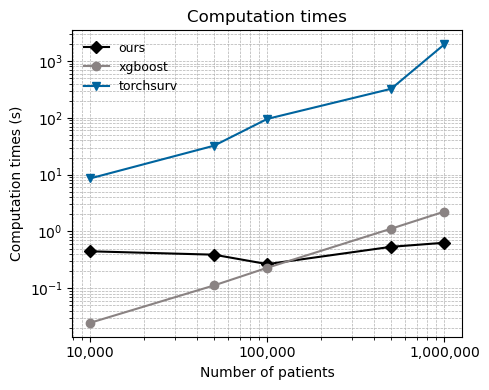

In [22]:
#################### Configs
min_n_patients = 5000


packages_style = {
    "survivalgpu":         {"label": "ours",            "color": "#000000", "marker": "D", "ls": "-"},
    "xgboost":             {"label": "xgboost",         "color": "#8A8383", "marker": "o", "ls": "-"},
    "torchsurv":           {"label": "torchsurv",       "color": "#00649E", "marker": "v", "ls": "-"},

}

packages_computation = ["survivalgpu", "xgboost", "torchsurv"]


def get_computation_times(package_name, dataset):

    n_patients = dataset[dataset["package"] == package_name]["n_patients"].values
    computation_times = dataset[dataset["package"] == package_name]["computation_time"].values

    return (n_patients, computation_times)
    


def plot_computation_times(ax, dataset, packages, packages_style, min_n_patients=0, min_max_y=False):
    dataset = dataset[dataset["n_patients"] >= min_n_patients]

    for pkg in packages:
        n_patients, comp_times = get_computation_times(pkg, dataset)
        ax.plot(n_patients, comp_times, **packages_style[pkg])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    
    if min_max_y:
        ax.set_ylim(min_max_y)

    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, which="both", ls="--", lw=0.5)

####################

fig, axs = plt.subplots(ncols=1, figsize=(5, 4))

plot_computation_times(axs, dataset, packages_computation, packages_style, min_n_patients = min_n_patients)
axs.set_title("Computation times")
axs.set_xlabel("Number of patients")
axs.set_ylabel("Computation times (s)")





# plot_speedup(axs[1], dataset_0c_1td, packages_speedup, packages_style=acceleration_rate_packages_style, reference_packages=reference_packages, min_n_patients = min_n_patients)
# axs[1].set_title("Acceleration rate of survivalGPU")
# axs[1].set_xlabel("Number of patients")
# axs[1].set_ylabel("Acceleration rate")


# plot_computation_times(axs[1, 0], dataset_10c_1td, packages_computation, packages_style)
# axs[1, 0].set_title("10 time-dependent covariates\n(computation times)")
# axs[1, 0].set_xlabel("Number of patients")
# axs[1, 0].set_ylabel("Computation times (s)")

# plot_speedup(axs[1, 1], dataset_10c_1td, packages_speedup, packages_style, reference_package)
# axs[1, 1].set_title("10 time-dependent covariates\n(speedup against R survival)")
# axs[1, 1].set_xlabel("Number of patients")
# axs[1, 1].set_ylabel("Speedup against R survival")

plt.tight_layout()
image_path = Path("/home/dev/analysis_survivalgpu/JSS/images")
plt.savefig(image_path / "benchmark_gpu.png")
plt.show()

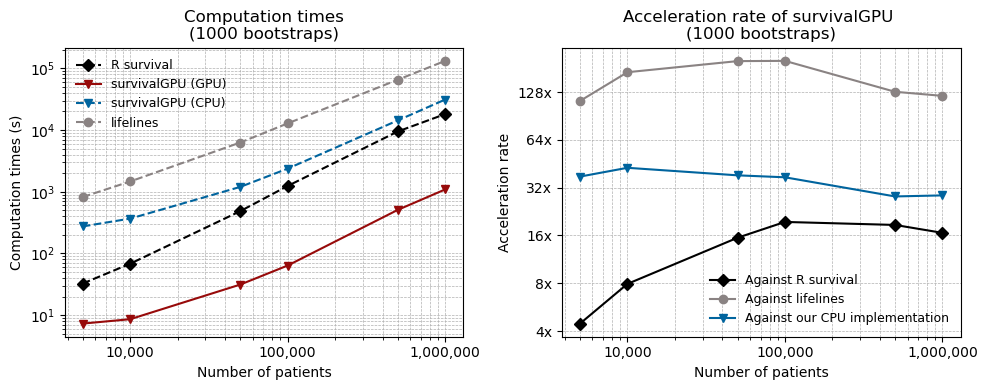

In [24]:
#################### Configs

min_n_patients = 5000
n_bootstraps = 1000  # Change this to adjust the bootstrap multiplier

data_path = Path("/home/dev/analysis_survivalgpu/JSS/Benchmark_cox/benchmark_results")

# Bootstrap dataset (only contains real bootstrap measurements for survivalGPU CUDA)
dataset_0c_1td_name_1000 = data_path / "large_bench_bootstrap_1000bs_0c_1td.csv"
dataset_0c_1td_1000 = pd.read_csv(dataset_0c_1td_name_1000)

# Base dataset (no bootstraps) — used to simulate bootstrap times for other packages
dataset_no_bootstraps_name = data_path / "bench_0c_1td.csv"
dataset_no_bootstraps = pd.read_csv(dataset_no_bootstraps_name)


# --- Build a unified dataset:
# - survivalGPU (CUDA): real bootstrap measurements from bootstrap dataset
# - All others: base times × n_bootstraps, renamed to match bootstrap package names

package_rename_map = {
    "cox_r_survival":            "bootstrap_r_survival",
    "cox_lifelines":             "bootstrap_lifelines",
    "cox_survival_gpu_cpu_f32":  "bootstrap_sgpu_cpu_f32",
}

simulated_rows = []
for cox_name, bootstrap_name in package_rename_map.items():
    rows = dataset_no_bootstraps[dataset_no_bootstraps["package"] == cox_name].copy()
    rows["mean_time_s"] = rows["mean_time_s"] * n_bootstraps
    rows["package"] = bootstrap_name
    simulated_rows.append(rows)

dataset_bootstrap_combined = pd.concat(
    [dataset_0c_1td_1000[dataset_0c_1td_1000["package"] == "bootstrap_sgpu_cuda_f32"]]
    + simulated_rows,
    ignore_index=True,
)


# --- Styles (same structure as first figure) ---

packages_style = {
    "bootstrap_r_survival":   {"label": "R survival",        "color": "#000000", "marker": "D", "ls": "--"},
    "bootstrap_lifelines":    {"label": "lifelines",         "color": "#8A8383", "marker": "o", "ls": "--"},
    "bootstrap_sgpu_cpu_f32": {"label": "survivalGPU (CPU)", "color": "#00649E", "marker": "v", "ls": "--"},
    "bootstrap_sgpu_cuda_f32":{"label": "survivalGPU (GPU)", "color": "#970A0A", "marker": "v", "ls": "-"},
}

acceleration_rate_packages_style = {
    "bootstrap_r_survival":   {"label": "Against R survival",             "color": "#000000", "marker": "D", "ls": "-"},
    "bootstrap_lifelines":    {"label": "Against lifelines",              "color": "#8A8383", "marker": "o", "ls": "-"},
    "bootstrap_sgpu_cpu_f32": {"label": "Against our CPU implementation", "color": "#00649E", "marker": "v", "ls": "-"},
}

packages_computation = ["bootstrap_r_survival", "bootstrap_sgpu_cuda_f32", "bootstrap_sgpu_cpu_f32", "bootstrap_lifelines"]
packages_speedup     = ["bootstrap_sgpu_cuda_f32"]
reference_packages   = ["bootstrap_r_survival", "bootstrap_lifelines", "bootstrap_sgpu_cpu_f32"]


# --- Same plot functions as first figure, operating on the combined dataset ---

def get_computation_times(package_name, dataset):
    n_patients = dataset[dataset["package"] == package_name]["n_patients"].values
    computation_times = dataset[dataset["package"] == package_name]["mean_time_s"].values
    return (n_patients, computation_times)


def plot_speedup(ax, dataset, packages, packages_style, reference_packages, min_n_patients=0, min_max_y=False):
    dataset = dataset[dataset["n_patients"] >= min_n_patients]

    _, times_sgpu_cuda = get_computation_times("bootstrap_sgpu_cuda_f32", dataset)

    for pkg in reference_packages:
        n_patients, times_ref = get_computation_times(pkg, dataset)
        ax.plot(n_patients, times_ref / times_sgpu_cuda, **packages_style[pkg])

    ax.set_xscale("log")
    ax.set_yscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}x"))
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, which="both", ls="--", lw=0.5)


def plot_computation_times(ax, dataset, packages, packages_style, min_n_patients=0, min_max_y=False):
    dataset = dataset[dataset["n_patients"] >= min_n_patients]

    for pkg in packages:
        n_patients, comp_times = get_computation_times(pkg, dataset)
        ax.plot(n_patients, comp_times, **packages_style[pkg])

    ax.set_xscale("log")
    ax.set_yscale("log")
    if min_max_y:
        ax.set_ylim(min_max_y)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, which="both", ls="--", lw=0.5)


####################

fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

plot_computation_times(axs[0], dataset_bootstrap_combined, packages_computation, packages_style, min_n_patients=min_n_patients)
axs[0].set_title(f"Computation times\n({n_bootstraps} bootstraps)")
axs[0].set_xlabel("Number of patients")
axs[0].set_ylabel("Computation times (s)")

plot_speedup(axs[1], dataset_bootstrap_combined, packages_speedup, packages_style=acceleration_rate_packages_style,
             reference_packages=reference_packages, min_n_patients=min_n_patients)
axs[1].set_title(f"Acceleration rate of survivalGPU \n({n_bootstraps} bootstraps)")
axs[1].set_xlabel("Number of patients")
axs[1].set_ylabel("Acceleration rate")
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y)}x"))


plt.tight_layout()
image_path = Path("/home/dev/analysis_survivalgpu/JSS/images")
plt.savefig(image_path / "benchmark_cox_bootstraps.png")
plt.show()

In [112]:
#################### Configs

min_n_patients = 1000

data_path = Path("/home/dev/analysis_survivalgpu/JSS/Benchmark_cox/benchmark_results")

# Bootstrap dataset (only contains real bootstrap measurements for survivalGPU CUDA)
dataset_0c_1td_name_1000 = data_path / "large_bench_bootstrap_1000bs_0c_1td.csv"
dataset_0c_1td_1000 = pd.read_csv(dataset_0c_1td_name_1000)

# Base dataset (no bootstraps) — used to simulate bootstrap times for other packages
dataset_no_bootstraps_name = data_path / "bench_0c_1td.csv"
dataset_no_bootstraps = pd.read_csv(dataset_no_bootstraps_name)


# --- Build a unified dataset:
# - survivalGPU (CUDA): real bootstrap measurements from bootstrap dataset
# - All others: base times × n_bootstraps, renamed to match bootstrap package names

package_rename_map = {
    "cox_r_survival":            "bootstrap_r_survival",
    "cox_lifelines":             "bootstrap_lifelines",
    "cox_survival_gpu_cpu_f32":  "bootstrap_sgpu_cpu_f32",
}

simulated_rows = []
for cox_name, bootstrap_name in package_rename_map.items():
    rows = dataset_no_bootstraps[dataset_no_bootstraps["package"] == cox_name].copy()
    rows["mean_time_s"] = rows["mean_time_s"] * n_bootstraps
    rows["package"] = bootstrap_name
    simulated_rows.append(rows)

dataset_bootstrap_combined = pd.concat(
    [dataset_0c_1td_1000[dataset_0c_1td_1000["package"] == "bootstrap_sgpu_cuda_f32"]]
    + simulated_rows,
    ignore_index=True,
)


# --- Styles (same structure as first figure) ---

packages_style = {
    "bootstrap_r_survival":   {"label": "R survival",        "color": "#000000", "marker": "D", "ls": "--"},
    "bootstrap_lifelines":    {"label": "lifelines",         "color": "#8A8383", "marker": "o", "ls": "--"},
    "bootstrap_sgpu_cpu_f32": {"label": "survivalGPU (CPU)", "color": "#00649E", "marker": "v", "ls": "--"},
    "bootstrap_sgpu_cuda_f32":{"label": "survivalGPU (GPU)", "color": "#970A0A", "marker": "v", "ls": "-"},
}

acceleration_rate_packages_style = {
    "bootstrap_r_survival":   {"label": "Against R survival",             "color": "#000000", "marker": "D", "ls": "-"},
    "bootstrap_lifelines":    {"label": "Against lifelines",              "color": "#8A8383", "marker": "o", "ls": "-"},
    "bootstrap_sgpu_cpu_f32": {"label": "Against our CPU implementation", "color": "#00649E", "marker": "v", "ls": "-"},
}

packages_computation = ["bootstrap_r_survival", "bootstrap_sgpu_cuda_f32", "bootstrap_sgpu_cpu_f32", "bootstrap_lifelines"]
packages_speedup     = ["bootstrap_sgpu_cuda_f32"]
reference_packages   = ["bootstrap_r_survival", "bootstrap_lifelines", "bootstrap_sgpu_cpu_f32"]


# --- Same plot functions as first figure, operating on the combined dataset ---

def get_computation_times(package_name, dataset):
    n_patients = dataset[dataset["package"] == package_name]["n_patients"].values
    computation_times = dataset[dataset["package"] == package_name]["mean_time_s"].values
    return (n_patients, computation_times)


def plot_speedup(ax, dataset, packages, packages_style, reference_packages, min_n_patients=0, min_max_y=False):
    dataset = dataset[dataset["n_patients"] >= min_n_patients]

    _, times_sgpu_cuda = get_computation_times("bootstrap_sgpu_cuda_f32", dataset)

    for pkg in reference_packages:
        n_patients, times_ref = get_computation_times(pkg, dataset)
        ax.plot(n_patients, times_ref / times_sgpu_cuda, **packages_style[pkg])

    ax.set_xscale("log")
    ax.set_yscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}x"))
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, which="both", ls="--", lw=0.5)


def plot_computation_times(ax, dataset, packages, packages_style, min_n_patients=0, min_max_y=False):
    dataset = dataset[dataset["n_patients"] >= min_n_patients]

    for pkg in packages:
        n_patients, comp_times = get_computation_times(pkg, dataset)
        ax.plot(n_patients, comp_times, **packages_style[pkg])

    ax.set_xscale("log")
    ax.set_yscale("log")
    if min_max_y:
        ax.set_ylim(min_max_y)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, which="both", ls="--", lw=0.5)


####################

fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

plot_computation_times(axs[0], dataset_bootstrap_combined, packages_computation, packages_style, min_n_patients=min_n_patients)
axs[0].set_title(f"Computation times\n({n_bootstraps} bootstraps)")
axs[0].set_xlabel("Number of patients")
axs[0].set_ylabel("Computation times (s)")

plot_speedup(axs[1], dataset_bootstrap_combined, packages_speedup, packages_style=acceleration_rate_packages_style,
             reference_packages=reference_packages, min_n_patients=min_n_patients)
axs[1].set_title(f"Acceleration rate of survivalGPU \n({n_bootstraps} bootstraps)")
axs[1].set_xlabel("Number of patients")
axs[1].set_ylabel("Acceleration rate")
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y)}x"))


plt.tight_layout()
image_path = Path("/home/dev/analysis_survivalgpu/JSS/images")
plt.savefig(image_path / "benchmark_cox_bootstraps.png")
plt.show()

,n_patients,n_rows,n_constant_covariates,n_time_dependent_covariates,package,mean_time_s,n_repeats,status
0,500,3710,0,1,cox_r_survival,0.005301,1,ok
1,500,3710,0,1,cox_lifelines,0.118734,1,ok
2,500,3710,0,1,cox_survival_gpu_cpu_f64,0.166855,1,ok
3,500,3710,0,1,cox_survival_gpu_cpu_f32,0.161088,1,ok
4,500,3710,0,1,cox_survival_gpu_cuda_f64,0.378509,1,ok
5,500,3710,0,1,cox_survival_gpu_cuda_f32,0.497505,1,ok
6,1000,7471,0,1,cox_r_survival,0.008319,1,ok
7,1000,7471,0,1,cox_lifelines,0.225316,1,ok
8,1000,7471,0,1,cox_survival_gpu_cpu_f64,0.182749,1,ok
9,1000,7471,0,1,cox_survival_gpu_cpu_f32,0.179668,1,ok


In [110]:
dataset_10c_1td

,n_patients,n_rows,n_constant_covariates,n_time_dependent_covariates,package,mean_time_s,n_repeats,status
0,500,3705,10,1,cox_r_survival,0.010176,1,ok
1,500,3705,10,1,cox_lifelines,0.176993,1,ok
2,500,3705,10,1,cox_survival_gpu_cpu_f64,0.387738,1,ok
3,500,3705,10,1,cox_survival_gpu_cpu_f32,0.383009,1,ok
4,500,3705,10,1,cox_survival_gpu_cuda_f64,1.265785,1,ok
5,500,3705,10,1,cox_survival_gpu_cuda_f32,1.354097,1,ok
6,1000,7387,10,1,cox_r_survival,0.035715,1,ok
7,1000,7387,10,1,cox_lifelines,0.319901,1,ok
8,1000,7387,10,1,cox_survival_gpu_cpu_f64,0.429394,1,ok
9,1000,7387,10,1,cox_survival_gpu_cpu_f32,0.425782,1,ok
